<a href="https://colab.research.google.com/github/bouhaddifatimaezzahra47-hash/Network_intrusion_detection/blob/main/Network_intrusion_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Detecting Malicious Network Traffic with ML (CICIDS2017)



In [3]:
import os
import zipfile
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import RobustScaler
from sklearn.neural_network import MLPRegressor

In [4]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
os.makedirs("/content/drive/MyDrive/SentinelAI/data/CIC-IDS2017",exist_ok=True)

# **understanding the zip**

---
The CICIDS2017 dataset is provided as a ZIP archive containing multiple CSV files. Each file represents network traffic collected during a specific day or attack scenario.


In this Notebook we will devide the dataset on two parts; one type of attacks detected by supervised ML (Random Forest) and a percentage detected by unsupervised ML(Autoencoder)


In [6]:
with zipfile.ZipFile("/content/drive/MyDrive/SentinelAI/data/CIC-IDS2017/MachineLearningCSV.zip","r") as zip_ref:
  zip_ref.printdir()


File Name                                             Modified             Size
MachineLearningCVE/                            2018-06-07 16:30:42            0
MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv 2018-06-07 16:26:40    225166395
MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv 2018-06-07 14:31:12    135078995
MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv 2018-06-07 14:22:46     52023263
MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv 2018-06-07 14:19:24     83102436
MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv 2018-06-07 14:13:44    176927918
MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv 2018-06-07 13:51:46     58316725
MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv 2018-06-07 13:42:28     76906168
MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv 2018-06-07 13:37:00     77123859


In [7]:
with zipfile.ZipFile("/content/drive/MyDrive/SentinelAI/data/CIC-IDS2017/MachineLearningCSV.zip","r") as zipf:
  content1=zipf.read("MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv")
  content2=zipf.read("MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv")
  content3=zipf.read("MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv")
  content4=zipf.read("MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv")
  content5=zipf.read("MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv")
  content6=zipf.read("MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv")
  content7=zipf.read("MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")
  content8=zipf.read("MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")


In [8]:
df1=pd.read_csv(io.BytesIO(content1))
df2=pd.read_csv(io.BytesIO(content2))
df3=pd.read_csv(io.BytesIO(content3))
df4=pd.read_csv(io.BytesIO(content4))
df5=pd.read_csv(io.BytesIO(content5))
df6=pd.read_csv(io.BytesIO(content6))
df7=pd.read_csv(io.BytesIO(content7))
df8=pd.read_csv(io.BytesIO(content8))
df_total=pd.concat([df1,df2,df3,df4,df5,df6,df7,df8],axis=0)
df_total = df_total.reset_index(drop=True)

##Feature Selection

Since this study is conducted in Google Colab, we selected only the most relevant features for network intrusion detection instead of using all the available features in the CICIDS2017 dataset.

This reduces memory usage and computational cost while keeping the features that are most informative for detecting network attacks.

The selected features are used throughout the preprocessing, training, evaluation, and explainability stages of this study.

In [9]:
df_total.columns = df_total.columns.str.strip()
print(df_total.columns.tolist())
x_features = df_total[[
    'Destination Port',
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Fwd Packet Length Max',
    'Fwd Packet Length Min',
    'Fwd Packet Length Mean',
    'Fwd Packet Length Std',
    'Bwd Packet Length Max',
    'Bwd Packet Length Min',
    'Bwd Packet Length Mean',
    'Bwd Packet Length Std',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Flow IAT Mean',
    'Flow IAT Std',
    'Flow IAT Max',
    'Flow IAT Min',
    'Fwd IAT Total',
    'Bwd IAT Total',
    'Fwd IAT Mean',
    'Fwd IAT Std',
    'Fwd IAT Max',
    'Fwd IAT Min',
    'Bwd IAT Mean',
    'Bwd IAT Std',
    'Bwd IAT Max',
    'Bwd IAT Min',
    'Fwd Packets/s',
    'Bwd Packets/s',
    'Min Packet Length',
    'Max Packet Length',
    'Packet Length Mean',
    'Packet Length Std',
    'Packet Length Variance',
    'FIN Flag Count',
    'SYN Flag Count',
    'RST Flag Count',
    'ACK Flag Count',
    'Average Packet Size',
    'Down/Up Ratio',
    'Init_Win_bytes_forward'
]]

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

##Understanding and Processing the Dataset

In [10]:
y_target=df_total['Label']

y_target.value_counts()

,count
Label,
BENIGN,2273097
DoS Hulk,231073
PortScan,158930
DDoS,128027
DoS GoldenEye,10293
FTP-Patator,7938
SSH-Patator,5897
DoS slowloris,5796
DoS Slowhttptest,5499


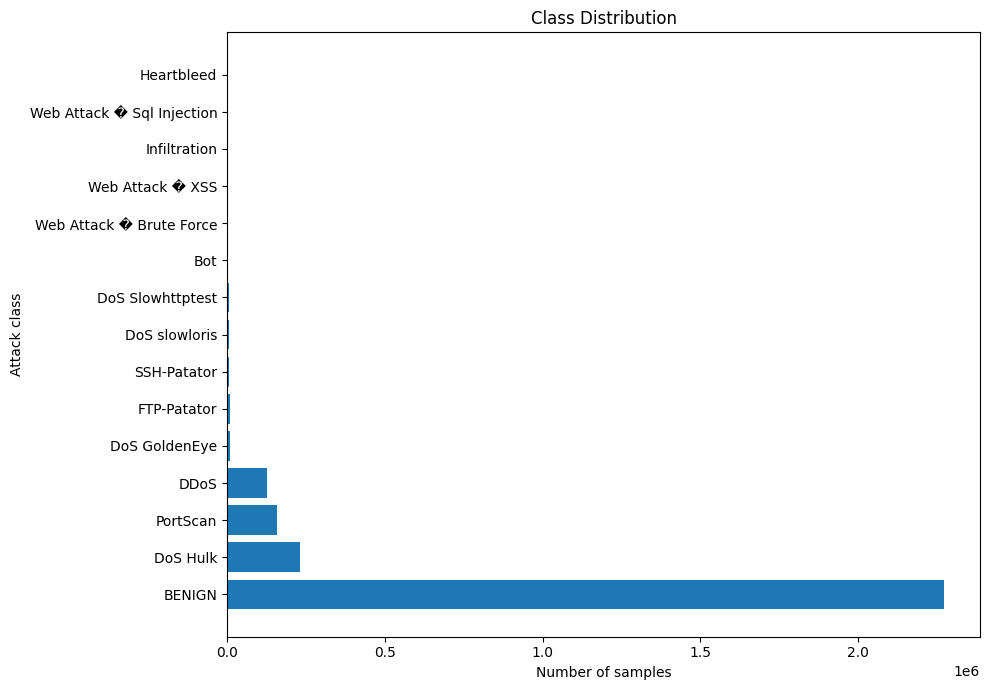

In [11]:
counts = y_target.value_counts()
plt.figure(figsize=(10, 7))
plt.barh(counts.index, counts.values)

plt.xlabel("Number of samples")
plt.ylabel("Attack class")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

In [12]:
#nul values
df_total.isnull().sum()

,0
Destination Port,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
...,...
Idle Mean,0
Idle Std,0
Idle Max,0
Idle Min,0


In [13]:
x_features.duplicated().sum()

np.int64(353492)

In [14]:
x_features =x_features.drop_duplicates(keep='first')

In [15]:
x_features.duplicated().sum()

np.int64(0)

In [16]:
np.isinf(x_features.select_dtypes(include='number')).sum().sum()

np.int64(2549)

In [17]:
np.isinf(x_features.select_dtypes(include='number')).sum()

,0
Destination Port,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
Total Length of Bwd Packets,0
Fwd Packet Length Max,0
Fwd Packet Length Min,0
Fwd Packet Length Mean,0
Fwd Packet Length Std,0


In [18]:
print((x_features['Flow Bytes/s']==np.inf).sum())
print((x_features['Flow Bytes/s']==-np.inf).sum())
print((x_features['Flow Packets/s']==np.inf).sum())
print((x_features['Flow Packets/s']==-np.inf).sum())


1117
0
1432
0


In [19]:
inf_rows = (
    np.isinf(x_features['Flow Bytes/s']) |
    np.isinf(x_features['Flow Packets/s'])
)
x_features = x_features[~inf_rows]
y_target = y_target.loc[x_features.index]
np.isinf(x_features.select_dtypes(include='number')).sum().sum()

np.int64(0)

In [20]:
print(x_features.shape)


(2475819, 44)


In [21]:
(x_features<0).sum()

,0
Destination Port,0
Flow Duration,83
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
Total Length of Bwd Packets,0
Fwd Packet Length Max,0
Fwd Packet Length Min,0
Fwd Packet Length Mean,0
Fwd Packet Length Std,0


In [22]:
#logicaly flow duration&flow bytes & flow packets can not be négative
negative_rows = (x_features < 0).any(axis=1)
x_features = x_features[~negative_rows]
y_target = y_target.loc[x_features.index]


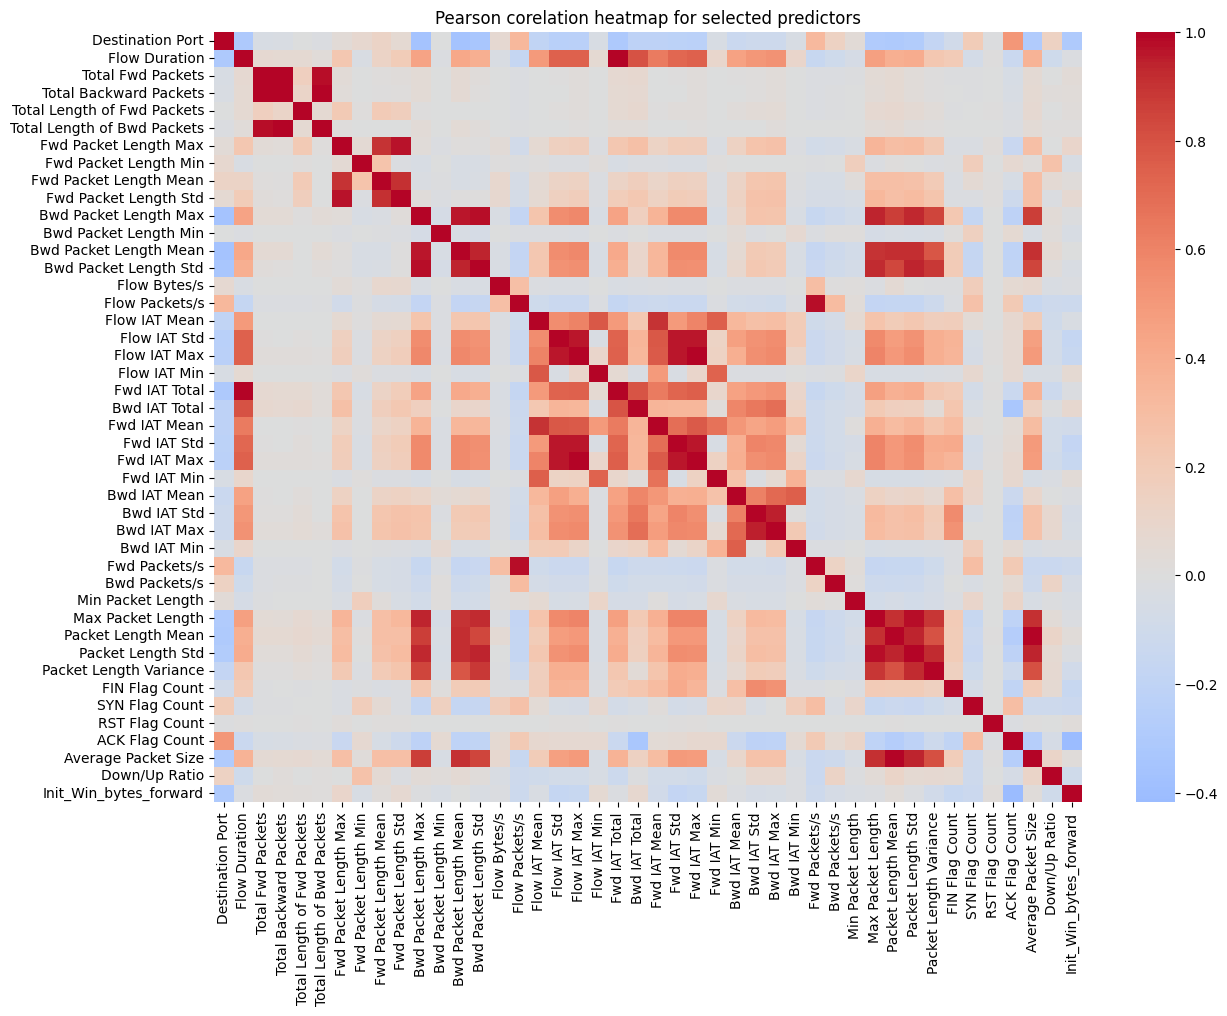

In [23]:
pearson_corr=x_features.corr(method='pearson')
plt.figure(figsize=(14,10))
sns.heatmap(pearson_corr, center=0, cmap='coolwarm',square=False,)
plt.title('Pearson corelation heatmap for selected predictors')
plt.show()

In [24]:
y_target.value_counts()

,count
Label,
BENIGN,1178550
DoS Hulk,172549
DDoS,127988
PortScan,90123
DoS GoldenEye,10281
FTP-Patator,5927
DoS slowloris,5382
DoS Slowhttptest,5228
SSH-Patator,3151


In [25]:
target=(y_target!='Heartbleed')&(y_target!='Infiltration')
print("the numbrt of total unseen dataset:" +str(target.value_counts()))

the numbrt of total unseen dataset:Label
True     1603240
False         42
Name: count, dtype: int64


## Spliting Data

In [26]:
x_seen=x_features[target]
y_seen=y_target[target]
x_unseen=x_features[~target]
y_unseen=y_target[~target]

In [27]:
x_train,x_test,y_train,y_test=train_test_split(x_seen,y_seen,test_size=0.2, random_state=42)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(1282592, 44)
(1282592,)
(320648, 44)
(320648,)


## Hyper Parameters tunig for Random Forest

In [28]:
x_tune, _, y_tune, _ = train_test_split(
    x_train,
    y_train,
    train_size=20000,
    stratify=y_train,
    random_state=42
)
classifier = RandomForestClassifier(random_state=42)
param_distributions = {
    'n_estimators': [50,100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}
random_search = RandomizedSearchCV(
    estimator=classifier,
    param_distributions=param_distributions,
    n_iter=3,
    scoring='f1_macro',
    cv=2,
    verbose=2,
    random_state=42,
    n_jobs=1
)
random_search.fit(x_tune, y_tune)
print("Best Parameters:", random_search.best_params_)


Fitting 2 folds for each of 3 candidates, totalling 6 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   2.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   2.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   3.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   3.0s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   2.9s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   3.6s
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}


In [29]:
final_classifer2=RandomForestClassifier(n_estimators=100,min_samples_split= 2, min_samples_leaf= 1, max_depth= 10, class_weight='balanced')
final_classifer2.fit(x_train, y_train)
y_pred2 = final_classifer2.predict(x_test)
proba2=final_classifer2.predict_proba(x_test)

## Evaluation Metrics for the model

evaluation metrics of random forest :
accuracy : 0.9582532870936354
precision : 0.6878967895701209
recall : 0.8979097331980086
F1 score : 0.7092920453034701


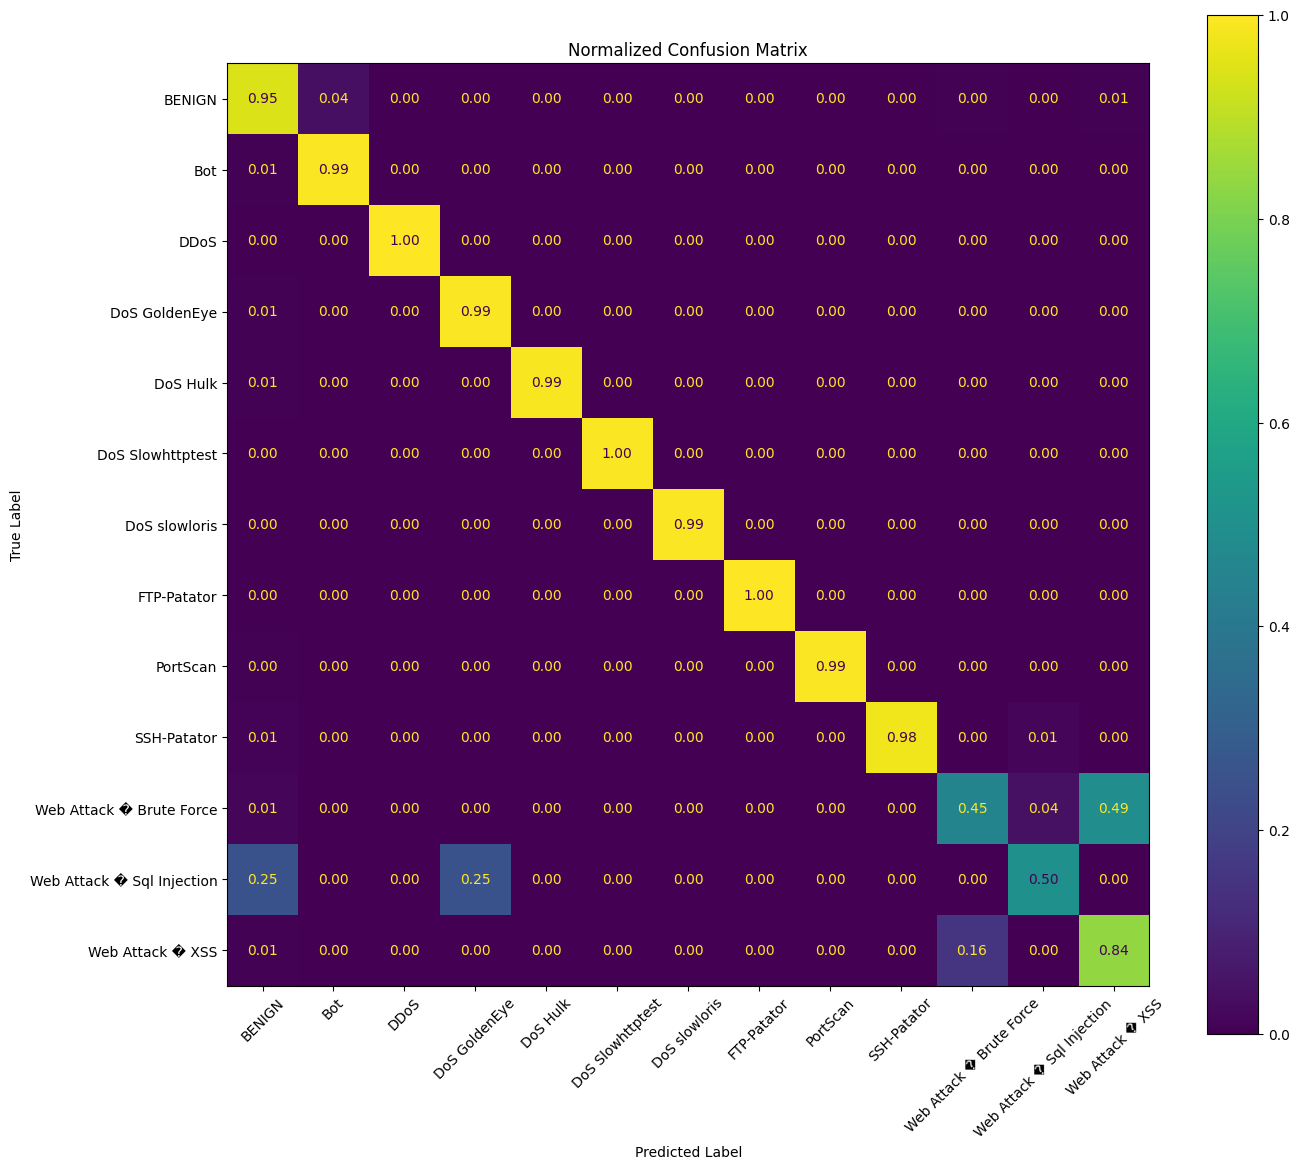

In [30]:
print("evaluation metrics of random forest :")
accuracy2=accuracy_score(y_test,y_pred2)
print("accuracy : "+str(accuracy2))
precision2=precision_score(y_test,y_pred2, average='macro')
print("precision : "+str(precision2))
recall2=recall_score(y_test,y_pred2, average='macro')
print("recall : "+str(recall2))
F12=f1_score(y_test,y_pred2, average="macro")
print("F1 score : "+str(F12))
#_______________________________confusion matrix_______________
fig, ax = plt.subplots(figsize=(14, 12))
confusion = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred2,
    normalize='true',
    xticks_rotation=45,
    values_format='.2f',
    ax=ax
)

ax.set_title("Normalized Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

#unsupervised ML (Autoencoder)

In [31]:
mask=(y_seen=='BENIGN')
y_seen=y_seen[mask]
x_seen=x_seen[mask]

## Scaling
the autoencoder is very sensitive to outliers

In [32]:
transformer=RobustScaler()
transformer.fit(x_seen)
scaled_x_seen=transformer.transform(x_seen)
scaled_x_unseen=transformer.transform(x_unseen)

## Spliting the data

In [33]:
X_train,X_val=train_test_split(scaled_x_seen,test_size=0.2, random_state=42)
sample_size = 150000
indices = np.random.choice(
    X_train.shape[0],
    sample_size,
    replace=False
)

X_train_sample = X_train[indices]

In [34]:
X_train_sample = np.clip(X_train_sample, -10, 10)
X_val = np.clip(X_val, -10, 10)
print(np.min(X_train_sample))
print(np.max(X_train_sample))
print(np.mean(X_train_sample))
print(np.std(X_train_sample))

scaled_x_unseen = np.clip(scaled_x_unseen, -10, 10)



-1.0
10.0
0.9564128091080748
2.3620476650448077


In [35]:
X_train_sample.shape

(150000, 44)

In [36]:
import tensorflow as tf
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model

## Train The Unsupervised model

In [37]:
latent_dim = 8

class Autoencoder(Model):
  def __init__(self, latent_dim):
    super(Autoencoder, self).__init__()
    self.latent_dim = latent_dim
    self.encoder = tf.keras.Sequential([
        layers.Dense(32, activation='relu'),
      layers.Dense(16, activation='relu'),
      layers.Dense(latent_dim, activation='relu'),
    ])
    self.decoder = tf.keras.Sequential([
      layers.Dense(16, activation='relu'),
      layers.Dense(32, activation='relu'),
      layers.Dense(44),
    ])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

autoencoder = Autoencoder(latent_dim)
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), loss=losses.MeanSquaredError())
autoencoder.fit(X_train_sample, X_train_sample,
                epochs=10,
                shuffle=True,
                 batch_size=256,
                validation_data=(X_val, X_val))

Epoch 1/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 6.4665 - val_loss: 6.2903
Epoch 2/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.0356 - val_loss: 5.7306
Epoch 3/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 5.3728 - val_loss: 5.0081
Epoch 4/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 4.6741 - val_loss: 4.3635
Epoch 5/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 4.1171 - val_loss: 3.9043
Epoch 6/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 3.7530 - val_loss: 3.6271
Epoch 7/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.5397 - val_loss: 3.4669
Epoch 8/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 3.4118 - val_loss: 3.3631
Epoch 9/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 3.3215 - val_loss: 3.2824
Epoch 10/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 3.2440 - val_loss: 3.2039


In [38]:
encoded_val=autoencoder.encoder(X_val).numpy()
decoded_val=autoencoder.decoder(encoded_val).numpy()

encoded_val_unseen=autoencoder.encoder(scaled_x_unseen).numpy()
decoded_val_unseen=autoencoder.decoder(encoded_val_unseen).numpy()

## Caluclate The reconstruction_errors

In [39]:
reconstruction_errors=np.mean(
    np.square(X_val - decoded_val),
    axis=1
)
print("Min:", np.min(reconstruction_errors))
print("Max:", np.max(reconstruction_errors))
print("Mean:", np.mean(reconstruction_errors))
print("Median:", np.median(reconstruction_errors))

Min: 0.007576127816743761
Max: 21.08674746892231
Mean: 3.203880276121189
Median: 2.4553591582363383


In [40]:
reconstruction_errors_unseen=np.mean(
    np.square(scaled_x_unseen- decoded_val_unseen),
    axis=1
)
print("Min:", np.min(reconstruction_errors))
print("Max:", np.max(reconstruction_errors))
print("Mean:", np.mean(reconstruction_errors))
print("Median:", np.median(reconstruction_errors))

Min: 0.007576127816743761
Max: 21.08674746892231
Mean: 3.203880276121189
Median: 2.4553591582363383


In [41]:
percentiles=np.percentile(reconstruction_errors,[90, 95, 99, 99.5, 99.9, 99.99])
print(percentiles)
treshold=5.65273164
anomaly_pred=reconstruction_errors_unseen>treshold
print("anomalies number:",np.sum(anomaly_pred))
print("Total unseen:", len(reconstruction_errors_unseen))
results = pd.DataFrame({
    'true_label': y_unseen.values,
    'reconstruction_error_unseen': reconstruction_errors_unseen,
    'anomaly': anomaly_pred
})

print(results)

[ 6.77591797  8.14973722 12.51723912 14.45700282 15.9516946  17.85903442]
anomalies number: 23
Total unseen: 42
      true_label  reconstruction_error_unseen  anomaly
0     Heartbleed                    19.108046     True
1     Heartbleed                    20.926551     True
2     Heartbleed                    20.215662     True
3     Heartbleed                    19.336318     True
4     Heartbleed                    20.984412     True
5     Heartbleed                    21.041357     True
6     Heartbleed                    19.008328     True
7   Infiltration                     5.954694     True
8   Infiltration                     3.514051    False
9   Infiltration                    11.111503     True
10  Infiltration                     3.366519    False
11  Infiltration                    12.625592     True
12  Infiltration                    12.189459     True
13  Infiltration                     3.945589    False
14  Infiltration                    12.335892     True
15  Infi

# trainig results


In [42]:
# the poor results because we didn't train the models on all features
print(results.groupby('true_label')['anomaly'].sum())

true_label
Heartbleed       7
Infiltration    16
Name: anomaly, dtype: int64
